# Applying `spatial_compare` to find spatially variable detection in large datasets 
This notebook illustrates the use of `spatial_detection_scores` on 3 datasets each with multiple acquisitions.  `spatial_detection_scores` compares each cell's total transcript counts to the distribution of total counts from a user-supplied reference. Here we use RNASeq and spatial datasets as the reference.

In [1]:
%load_ext autoreload 
%matplotlib inline
%autoreload 2
import pathlib
import anndata as ad
import pandas as pd
import numpy as np
import json
import gzip
import shutil
import subprocess
from spatial_compare import SpatialCompare, spatial_detection_scores, compare_reference_and_spatial, summarize_and_plot 
from matplotlib import pyplot as plt
import seaborn as sns

#upset plots and set diagrams are for some exploratory visualizations
# #from matplotlib_set_diagrams import EulerDiagram

In [2]:
CATEGORY_COLUMN  = "subclass_name"
SAMPLE_COLUMN = "brain_section_label"
XY_COLUMNS = ["x", "y"]

In [3]:
# complete marmoset collection:
PATH_TO_MULTI_SECTION_DATA = "/Users/brianl/Downloads/Xenium-CJ23.56.004-Tank-hemisphere-47sections-locked-20250307_annotated-v20250617_mmc_mapped.h5ad"


mad = ad.read_h5ad(PATH_TO_MULTI_SECTION_DATA)

In [4]:
mad

AnnData object with n_obs × n_vars = 10455077 × 300
    obs: 'brain_section_barcode', 'brain_section_label', 'x', 'y', 'xenium_filename', 'total_counts', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'counts_qc_pass', 'z_order_across_slabs', 'z_depth_ap_nominal', 'z_depth_in_slab', 'basal_ganglia_and_adjacent', 'subcortical', 'STR', 'Cd', 'Pu', 'GP', 'GPe', 'GPi', 'SN', 'STH', 'VP', 'hierarchy_consistent', 'neighborhood_label', 'neighborhood_name', 'neighborhood_bootstrapping_probability', 'neighborhood_aggregate_probability', 'neighborhood_correlation_coefficient', 'class_label', 'class_name', 'class_bootstrapping_probability', 'class_aggregate_probability', 'class_correlation_coefficient', 'subclass_label', 'subclass_name', 'subclass_bootstrapping_probability', 'subclass_aggregate_probability', 'subclass_c

In [ ]:
# marmoset rnaseq:
mref = ad.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/mFISH/brianl/marmoset_BG_atlas/mapping/prelim_HMBA_marmoset_xenium_genes.h5ad")

In [ ]:
#adjust column names to match mapmycells results
mref.obs['HMBA_Macaque_Consensus-Group_label_Hierarchical_name'] = mref.obs['HMBA_Macaque_Consensus-Group_label_Hierarchical'].values

# RNASeq can be normalized to spatial data via a linear fit
the `compare_reference_and_spatial` modifies the reference transcript counts for use `spatial_detection_scores`

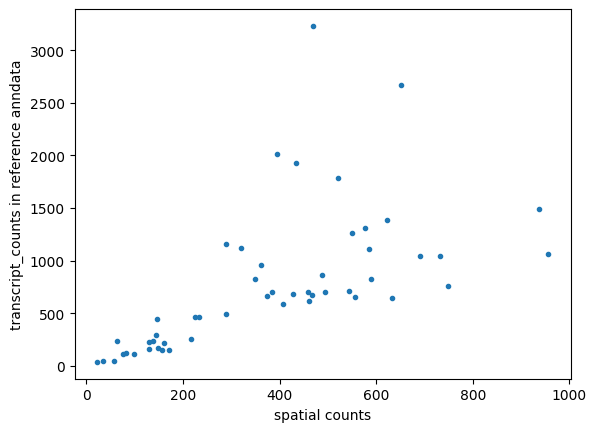

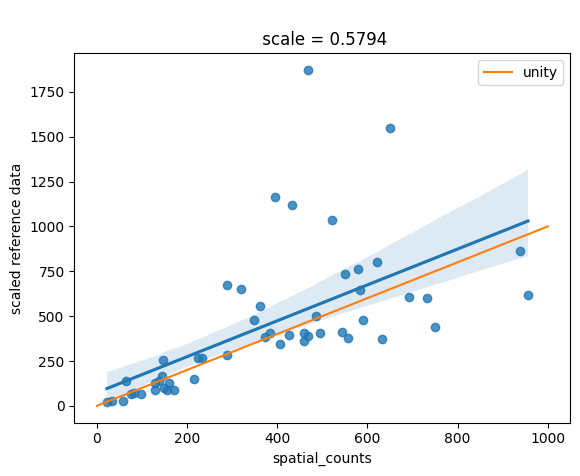

In [ ]:

compare_reference_and_spatial(mref,mad, 
                                  category='HMBA_Macaque_Consensus-Group_label_Hierarchical_name', layer_field = None, 
                                  plot_stuff=True,
                                  target_obs_key = "transcript_counts", ok_to_clobber=True)


# Now we can use this RNASeq data and the whole spatial dataset as references for each section in the marmoset anndata object

In [10]:
# loop over individual sections, comparing each to the whole dataset as reference
# precompute reference means/stds once so they aren't recalculated for every section
all_means = mad.obs.groupby(CATEGORY_COLUMN, observed=True)['transcript_counts'].mean()
all_stds = mad.obs.groupby(CATEGORY_COLUMN, observed=True)['transcript_counts'].std()

sds_against_all = {}
for ii,z in enumerate(sorted(list( mad.obs[SAMPLE_COLUMN].unique()))):
    sds_against_all[z]=spatial_detection_scores(mad[mad.obs[SAMPLE_COLUMN]==z,:].obs, all_means, all_stds, query_name=str(z),
                                category =CATEGORY_COLUMN, n_bins=30, plot_stuff=False, xy_columns=XY_COLUMNS)


In [ ]:
# loop over individual sections, comparing each to the RNASeq dataset as reference
# precompute reference means/stds once so they aren't recalculated for every section
rnaseq_means = mref.obs.groupby('HMBA_Macaque_Consensus-Group_label_Hierarchical_name', observed=True)['transcript_counts'].mean()
rnaseq_stds = mref.obs.groupby('HMBA_Macaque_Consensus-Group_label_Hierarchical_name', observed=True)['transcript_counts'].std()

sds_against_rnaseq = {}
for ii,z in enumerate(sorted(list( mad.obs.filename.unique()))):

    s = spatial_detection_scores(mad[mad.obs.filename==z,:].obs, rnaseq_means, rnaseq_stds, query_name=str(z),
                                 category ='HMBA_Macaque_Consensus-Group_label_Hierarchical_name', n_bins=30, plot_stuff=False)
    sds_against_rnaseq[z]=s


# now that we have these results, we can summarize and plot them 

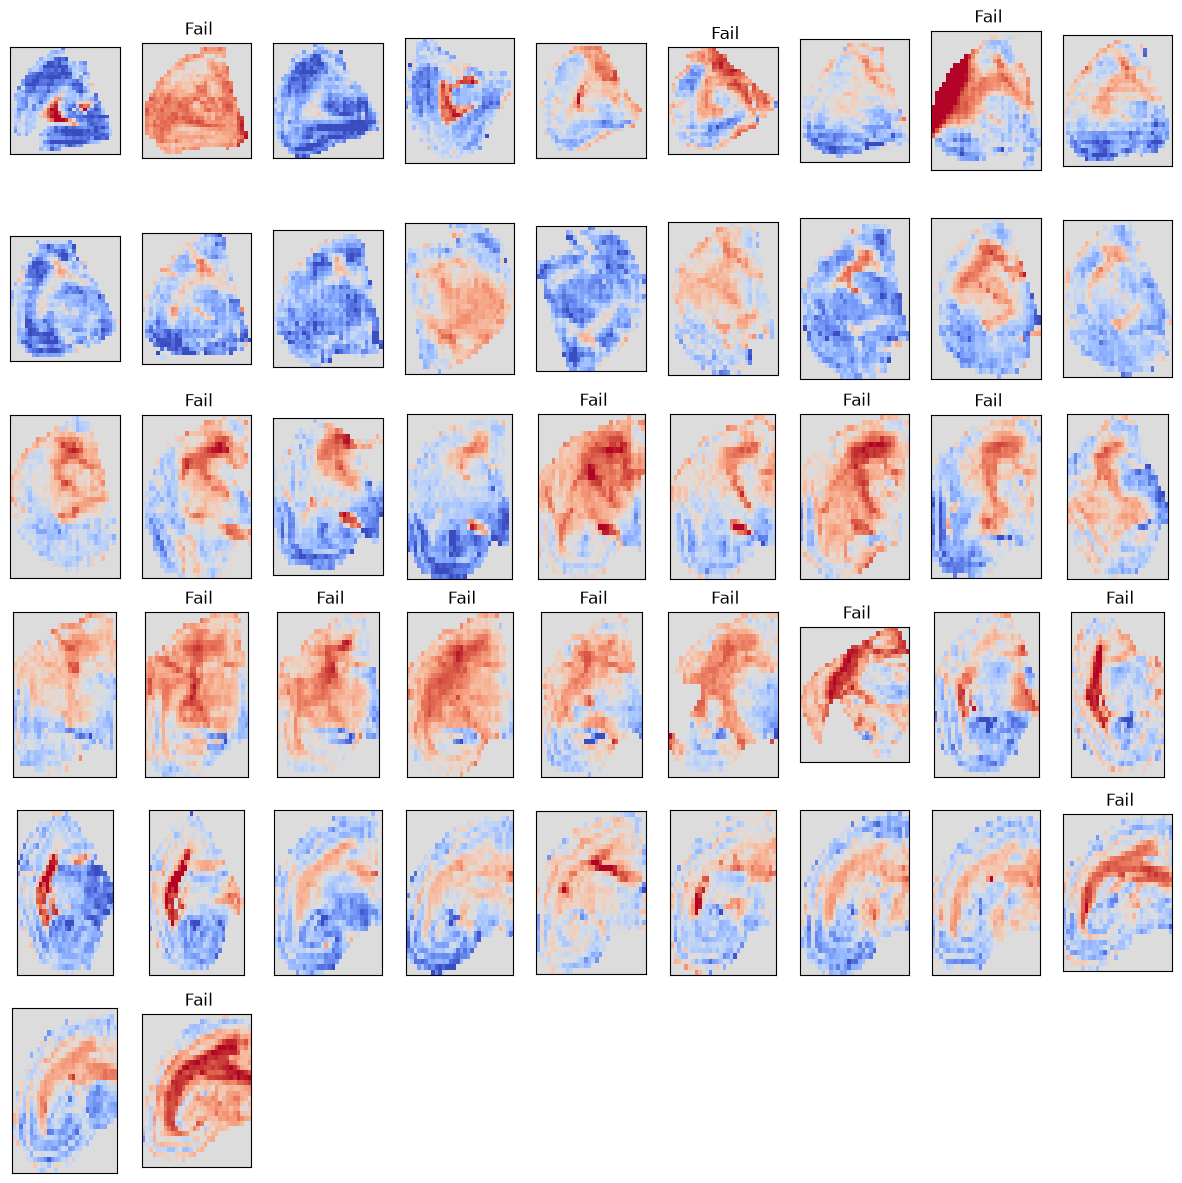

In [12]:
#results_rnaseq=summarize_and_plot(sds_against_rnaseq)
results_spatial=summarize_and_plot(sds_against_all)

### and the results visualization is further added to a dataframe here with some data-specific tweaks

In [ ]:
fails_vs_all = [r["key"] for r in results_spatial if r["failed"]]
fails_vs_rnaseq = [r["key"] for r in results_rnaseq if r["failed"]]

# make a dataframe for detailed QC per run
summary_df = pd.DataFrame(mad.obs.filename.unique(), columns=["filename"])
summary_df["spatial_compare_to_rnaseq_fail"] = [f in fails_vs_rnaseq for f in summary_df.filename]
summary_df["spatial_compare_to_spatial_fail"] = [f in fails_vs_all for f in summary_df.filename]
summary_df["section_name"] = [mad.obs.loc[mad.obs.xenium_filename==name,["section_name"]].values[0][0] for name in summary_df.filename]
summary_df["unique_acquisition_date"] = [mad.obs.loc[mad.obs.xenium_filename==name,["unique_acquisition_date"]].values[0][0] for name in summary_df.filename]

summary_df.sort_values("section_name", ignore_index=True, inplace=True)
wdr_fails=["CJ23.56.004.CX.42.09.06","CJ23.56.004.CX.42.11.06","CJ23.56.004.CX.42.11.07","CJ23.56.004.CX.42.12.07",
           "CJ23.56.004.CX.42.12.06","CJ23.56.004.CX.42.21.07","CJ23.56.004.CX.43.02.07","CJ23.56.004.CX.43.03.06",
           "CJ23.56.004.CX.43.04.07","CJ23.56.004.CX.43.05.06","CJ23.56.004.CX.43.09.06"]
redos=["CJ23.56.004.CX.42.09.07","CJ23.56.004.CX.42.11.07","CJ23.56.004.CX.42.12.06","CJ23.56.004.CX.43.04.06",
       "CJ23.56.004.CX.43.05.07","CJ23.56.004.CX.44.07.07","CJ23.56.004.CX.44.08.07","CJ23.56.004.CX.44.11.07","CJ23.56.004.CX.44.12.06"]
         


summary_df["WDR_fail"] = [f in wdr_fails for f in summary_df.section_name]
summary_df["is_redo"] = [f in redos for f in summary_df.section_name]


In [ ]:
summary_df.to_csv("/allen/programs/celltypes/workgroups/rnaseqanalysis/mFISH/brianl/marmoset_BG_atlas/intermediate_sections_HMBA_mapped_QC_info.csv")

In [ ]:
mad.obs = pd.merge(mad.obs,summary_df.loc[:, ["spatial_compare_to_rnaseq_fail", 	"spatial_compare_to_spatial_fail", 	"section_name" , 	'WDR_fail' ,	'is_redo']], on = "section_name")


In [ ]:
mad.write_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/mFISH/brianl/marmoset_BG_atlas/intermediate_sections_HMBA_mapped_QC_obs.h5ad")

In [ ]:
memberships = [[col for col in ['spatial_compare_to_rnaseq_fail',
       'spatial_compare_to_spatial_fail', 'WDR_fail'] if summary_df.loc[summary_df.section_name==a,[col]].values.all()] for a in summary_df.section_name]

us = UpSet(from_memberships(memberships), subset_size='count')

us

for_euler = {a:us.intersections[a] for a in us.intersections.index}


us.intersections

for_euler

summary_df.loc[:,['spatial_compare_to_rnaseq_fail',
       'spatial_compare_to_spatial_fail', 'WDR_fail']].sum(axis=0)

for_euler_int = {}
# this implementation of Euler diagrams doesn't include non-intersecting categories. 
# so things that pass all QC categories (first column in upset plot) don't actually 
for key in for_euler.keys():
    if np.sum(key)==0:
        continue
    for_euler_int[tuple([int(b) for b in key])] = for_euler[key]


/allen/programs/celltypes/workgroups/hct/brianlong/conda/envs/sis-hpc/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


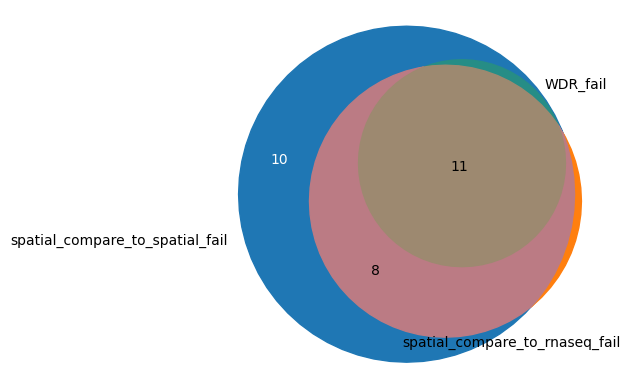

In [ ]:
EulerDiagram(for_euler_int, set_labels = list(us.totals.keys()))

In [ ]:
# complete sea-ad collection:

adad = ad.read_h5ad("/allen/programs/celltypes/workgroups/hct/emilyg/mapping/202407_xenium/final_gene_panel_mapping/mtg_mapping/COMBO_2024-10-29_52sects_mtg_and_pfc_mapping_and_gaston.h5ad")

/allen/programs/celltypes/workgroups/hct/brianlong/conda/envs/sis-hpc/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
adad.obs["x_centroid"]=adad.obsm["spatial_cirro"][:,0]
adad.obs["y_centroid"]=adad.obsm["spatial_cirro"][:,1]


In [ ]:
adad.var.to_csv("/allen/programs/celltypes/workgroups/hct/SEA-AD/MERSCOPE/Xenium_Validation/DLPFC_2_var.csv")

# Repeat these steps with a different dataset

In [ ]:
# subsetted the RNASeq reference thusly:
#adrna = ad.read_h5ad("/allen/programs/celltypes/workgroups/hct/SEA-AD/Multiregion/SEAAD_MTG_RNAseq_final-nuclei.2024-02-13.h5ad")
#dlpfc_var = pd.read_csv("/allen/programs/celltypes/workgroups/hct/SEA-AD/MERSCOPE/Xenium_Validation/DLPFC_2_var.csv",index_col=0)
# xgenes = list(dlpfc_var.index)
# mtg_ref = adrna[:,xgenes]
# mtg_ref.write_h5ad("/allen/programs/celltypes/workgroups/hct/SEA-AD/MERSCOPE/Xenium_Validation/MTG_RNASeq_Xenium_panel2_genes.h5ad")

In [ ]:
mtg_ref= ad.read_h5ad("/allen/programs/celltypes/workgroups/hct/SEA-AD/MERSCOPE/Xenium_Validation/MTG_RNASeq_Xenium_panel2_genes.h5ad")

In [ ]:
mtg_ref.obs["MTG_subclass_name"] = mtg_ref.obs["Subclass"].values

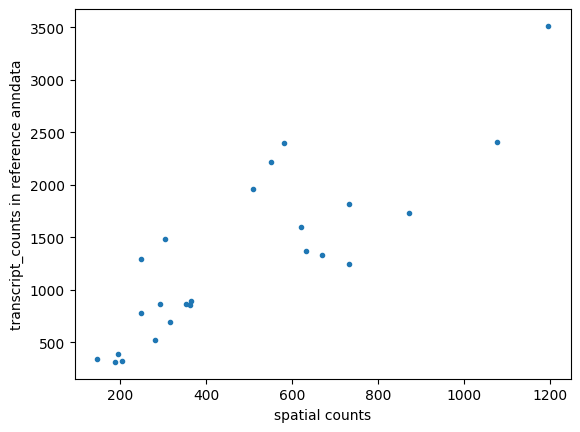

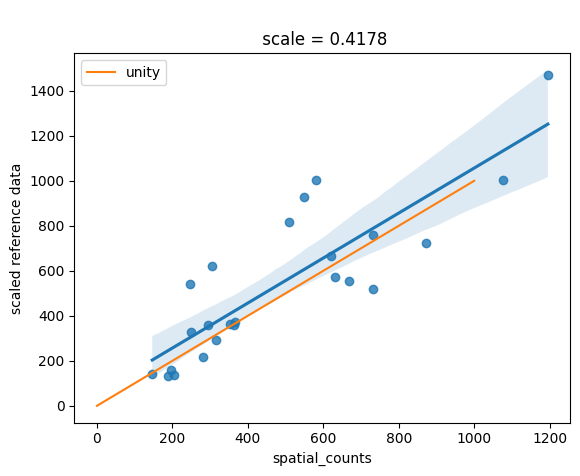

In [ ]:
compare_reference_and_spatial(mtg_ref,adad, 
                                  category="MTG_subclass_name", layer_field = "UMIs", 
                                  plot_stuff=True,
                                  target_obs_key = "transcript_counts", ok_to_clobber=True)


In [ ]:
# loop over individual sections, comparing each to the whole dataset as reference
# precompute reference means/stds once so they aren't recalculated for every section
ad_all_means = adad.obs.groupby('subclass_name', observed=True)['transcript_counts'].mean()
ad_all_stds = adad.obs.groupby('subclass_name', observed=True)['transcript_counts'].std()

ad_against_spatial = {}
for ii,z in enumerate(sorted(list( adad.obs.filename.unique()))):

    s = spatial_detection_scores(adad[adad.obs.filename==z,:].obs, ad_all_means, ad_all_stds, query_name=str(z),
                                 category ='subclass_name', n_bins=30, plot_stuff=False)
    ad_against_spatial[z]=s


In [ ]:
# loop over individual sections, comparing each to the RNASeq  dataset as reference
# precompute reference means/stds once so they aren't recalculated for every section
mtg_ref_means = mtg_ref.obs.groupby('MTG_subclass_name', observed=True)['transcript_counts'].mean()
mtg_ref_stds = mtg_ref.obs.groupby('MTG_subclass_name', observed=True)['transcript_counts'].std()

ad_against_rna = {}
for ii,z in enumerate(sorted(list( adad.obs.filename.unique()))):

    s = spatial_detection_scores(adad.obs.loc[adad.obs.filename==z,:], mtg_ref_means, mtg_ref_stds, query_name=str(z),
                                 category ='MTG_subclass_name', n_bins=30, plot_stuff = False)
    ad_against_rna[z]=s


In [ ]:
# make a dataframe for detailed QC per run
ad_res_rnaseq =summarize_and_plot(ad_against_rna, plot_stuff=False)
ad_res_spatial =summarize_and_plot(ad_against_spatial, plot_stuff=False)

ad_fails_vs_rnaseq = [a["key"] for a in ad_res_rnaseq if a["failed"]]
ad_fails_vs_all = [a["key"] for a in ad_res_spatial if a["failed"]]
ad_fails_outright = [ "1394067467", "1376583035", "1397625705", "1397625702"]
ad_fails_requires_mask = ["1397627946", "1394071405", "1397628209", "1394071402",
                          "1394066176", "1394068583", "1394067858", "1394066589", 
                          "1394065584", "1397627727", "1397627830", "1397627825", 
                          "1394067472", "1394067096", "1388473577", "1379033437"]


ad_summary_df = pd.DataFrame(adad.obs.filename.unique(), columns=["filename"])
ad_summary_df["barcode"] = [adad.obs.loc[adad.obs.filename==name,["barcode"]].values[0][0] for name in ad_summary_df.filename]
ad_summary_df["qc_review_fail"] = [f in ad_fails_outright for f in ad_summary_df.barcode]
ad_summary_df["qc_review_mask_required"] = [f in ad_fails_requires_mask for f in ad_summary_df.barcode]
ad_summary_df["spatial_compare_to_rnaseq_fail"] = [f in ad_fails_vs_rnaseq for f in ad_summary_df.filename]
ad_summary_df["spatial_compare_to_spatial_fail"] = [f in ad_fails_vs_all for f in ad_summary_df.filename]
ad_summary_df["section_name"] = [adad.obs.loc[adad.obs.filename==name,["specimen_ID"]].values[0][0] for name in ad_summary_df.filename]


ad_summary_df.sort_values("section_name", ignore_index=True, inplace=True)    


# generate pieces needed for upset plot and Euler diagram

memberships = [[col for col in ['spatial_compare_to_rnaseq_fail',
                               'spatial_compare_to_spatial_fail',
                                "qc_review_mask_required","qc_review_fail"] if ad_summary_df.loc[summary_df.section_name==a,[col]].values.all()] for a in summary_df.section_name]

us = UpSet(from_memberships(memberships), subset_size='count')

us

for_euler = {a:us.intersections[a] for a in us.intersections.index}

/allen/programs/celltypes/workgroups/hct/brianlong/conda/envs/sis-hpc/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


In [ ]:
us.intersections

spatial_compare_to_spatial_fail  spatial_compare_to_rnaseq_fail  qc_review_mask_required  qc_review_fail
False                            False                           False                    False             18
True                             False                           False                    False              4
False                            False                           True                     False              9
                                                                 False                    True               1
True                             True                            False                    False             10
                                 False                           False                    True               1
                                 True                            True                     False              7
                                                                 False                    True               2
       

In [ ]:
for_euler

{(False, False, False, False): 18,
 (True, False, False, False): 4,
 (False, False, True, False): 9,
 (False, False, False, True): 1,
 (True, True, False, False): 10,
 (True, False, False, True): 1,
 (True, True, True, False): 7,
 (True, True, False, True): 2,
 (True, True, True, True): 14}

In [ ]:
for_euler_int = {}
# this implementation of Euler diagrams doesn't include non-intersecting categories. 
# so things that pass all QC categories (first column in upset plot) don't actually 
for key in for_euler.keys():
    if np.sum(key)==0:
        continue
    for_euler_int[tuple([int(b) for b in key])] = for_euler[key]

In [ ]:
for_euler_int

{(1, 0, 0, 0): 4,
 (0, 0, 1, 0): 9,
 (0, 0, 0, 1): 1,
 (1, 1, 0, 0): 10,
 (1, 0, 0, 1): 1,
 (1, 1, 1, 0): 7,
 (1, 1, 0, 1): 2,
 (1, 1, 1, 1): 14}

In [ ]:
list(us.totals.keys())

['spatial_compare_to_spatial_fail',
 'spatial_compare_to_rnaseq_fail',
 'qc_review_mask_required',
 'qc_review_fail']

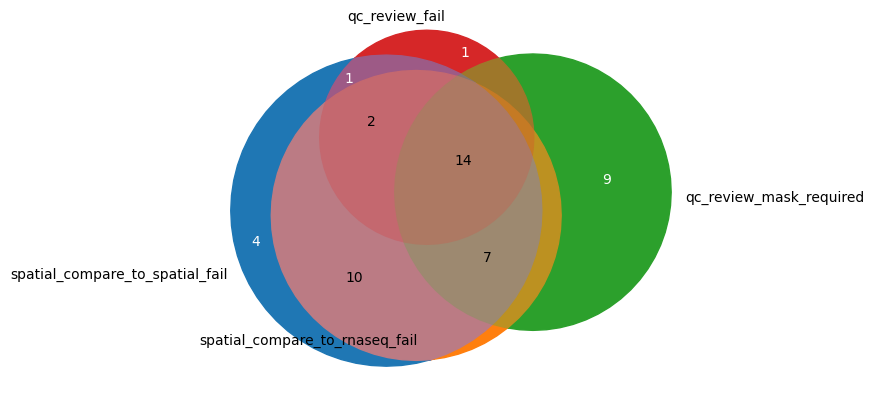

In [ ]:
for_euler_int

EulerDiagram(for_euler_int, set_labels = list(us.totals.keys()))

In [ ]:
summary_df.loc[:,["spatial_compare_to_rnaseq_fail", 	"spatial_compare_to_spatial_fail"]].sum(axis=0)

spatial_compare_to_rnaseq_fail     19
spatial_compare_to_spatial_fail    29
dtype: int64

In [ ]:
ad_summary_df.loc[:,["spatial_compare_to_rnaseq_fail", 	"spatial_compare_to_spatial_fail",'qc_review_fail', 'qc_review_mask_required']].sum(axis=0)

spatial_compare_to_rnaseq_fail     19
spatial_compare_to_spatial_fail    24
qc_review_fail                      4
qc_review_mask_required            16
dtype: int64

In [ ]:
ad_summary_df.columns

Index(['filename', 'barcode', 'qc_review_fail', 'qc_review_mask_required',
       'spatial_compare_to_rnaseq_fail', 'spatial_compare_to_spatial_fail',
       'section_name'],
      dtype='object')

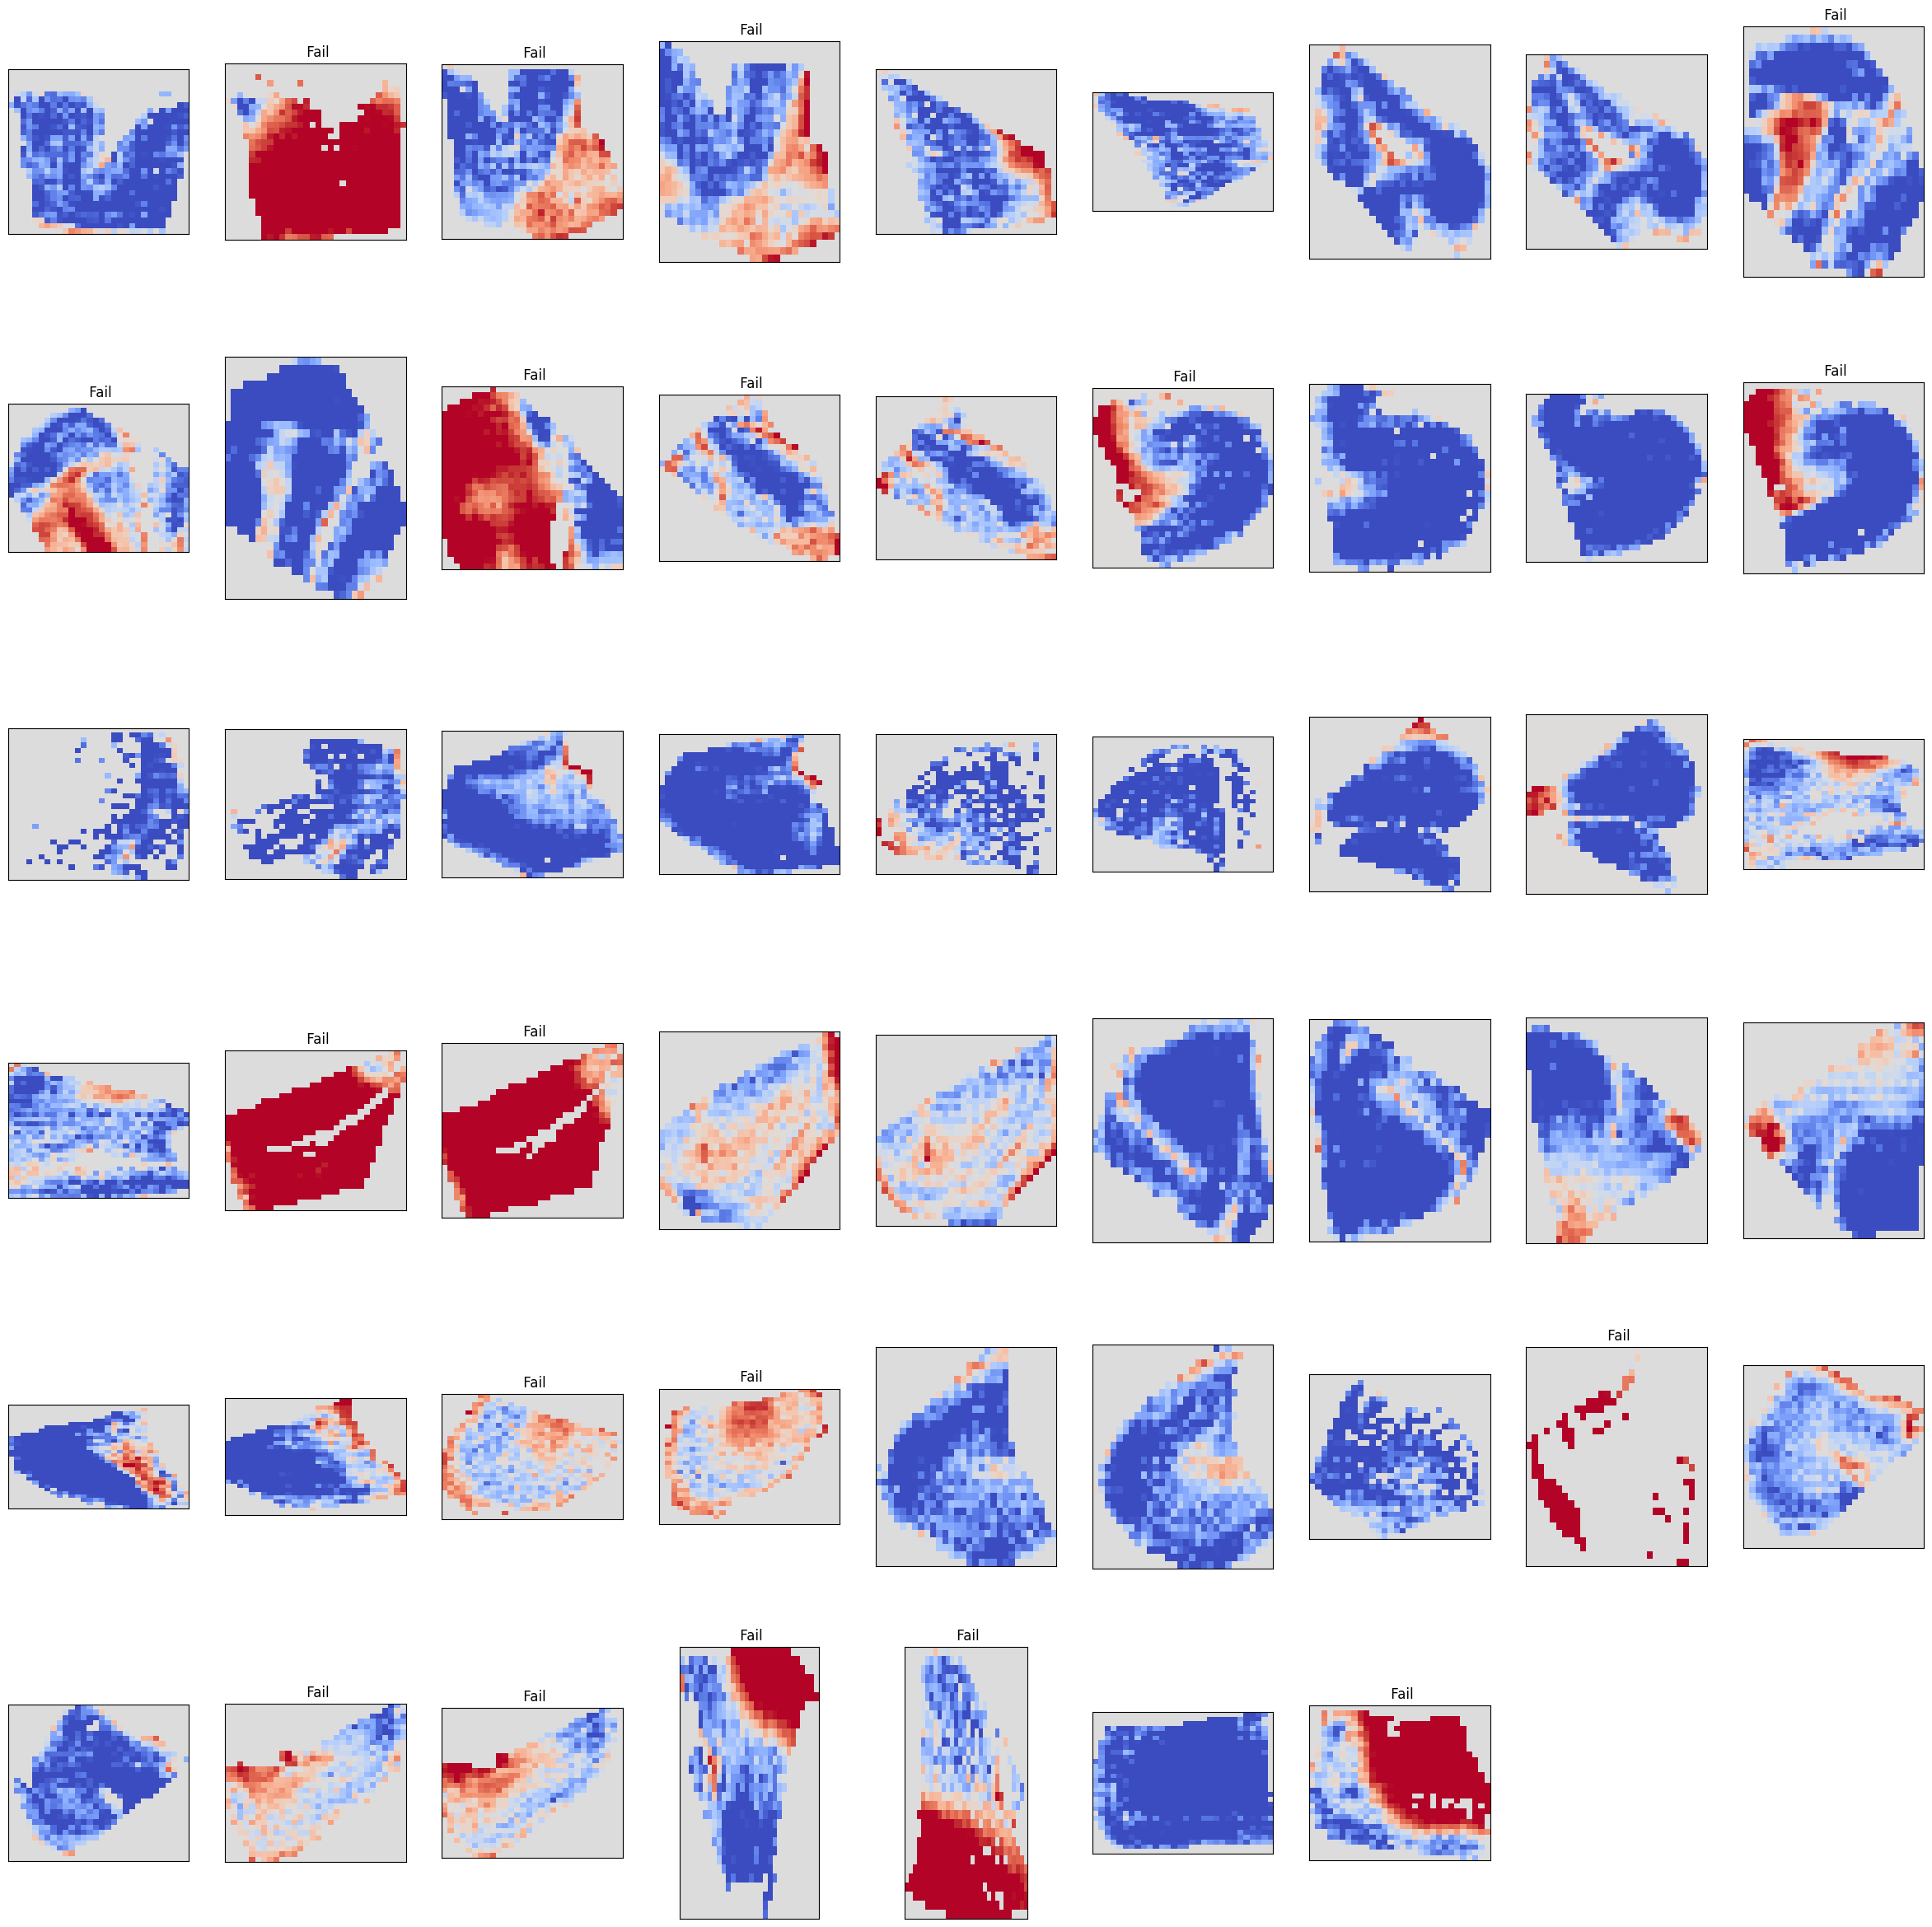

In [ ]:
title_mapping = {key:ad_summary_df.loc[ad_summary_df.filename==key,:].barcode.values[0] 
                 for key in ad_against_rna.keys() if key in list(ad_summary_df.filename)}
a=summarize_and_plot(ad_against_rna,  figsize=[30,30])

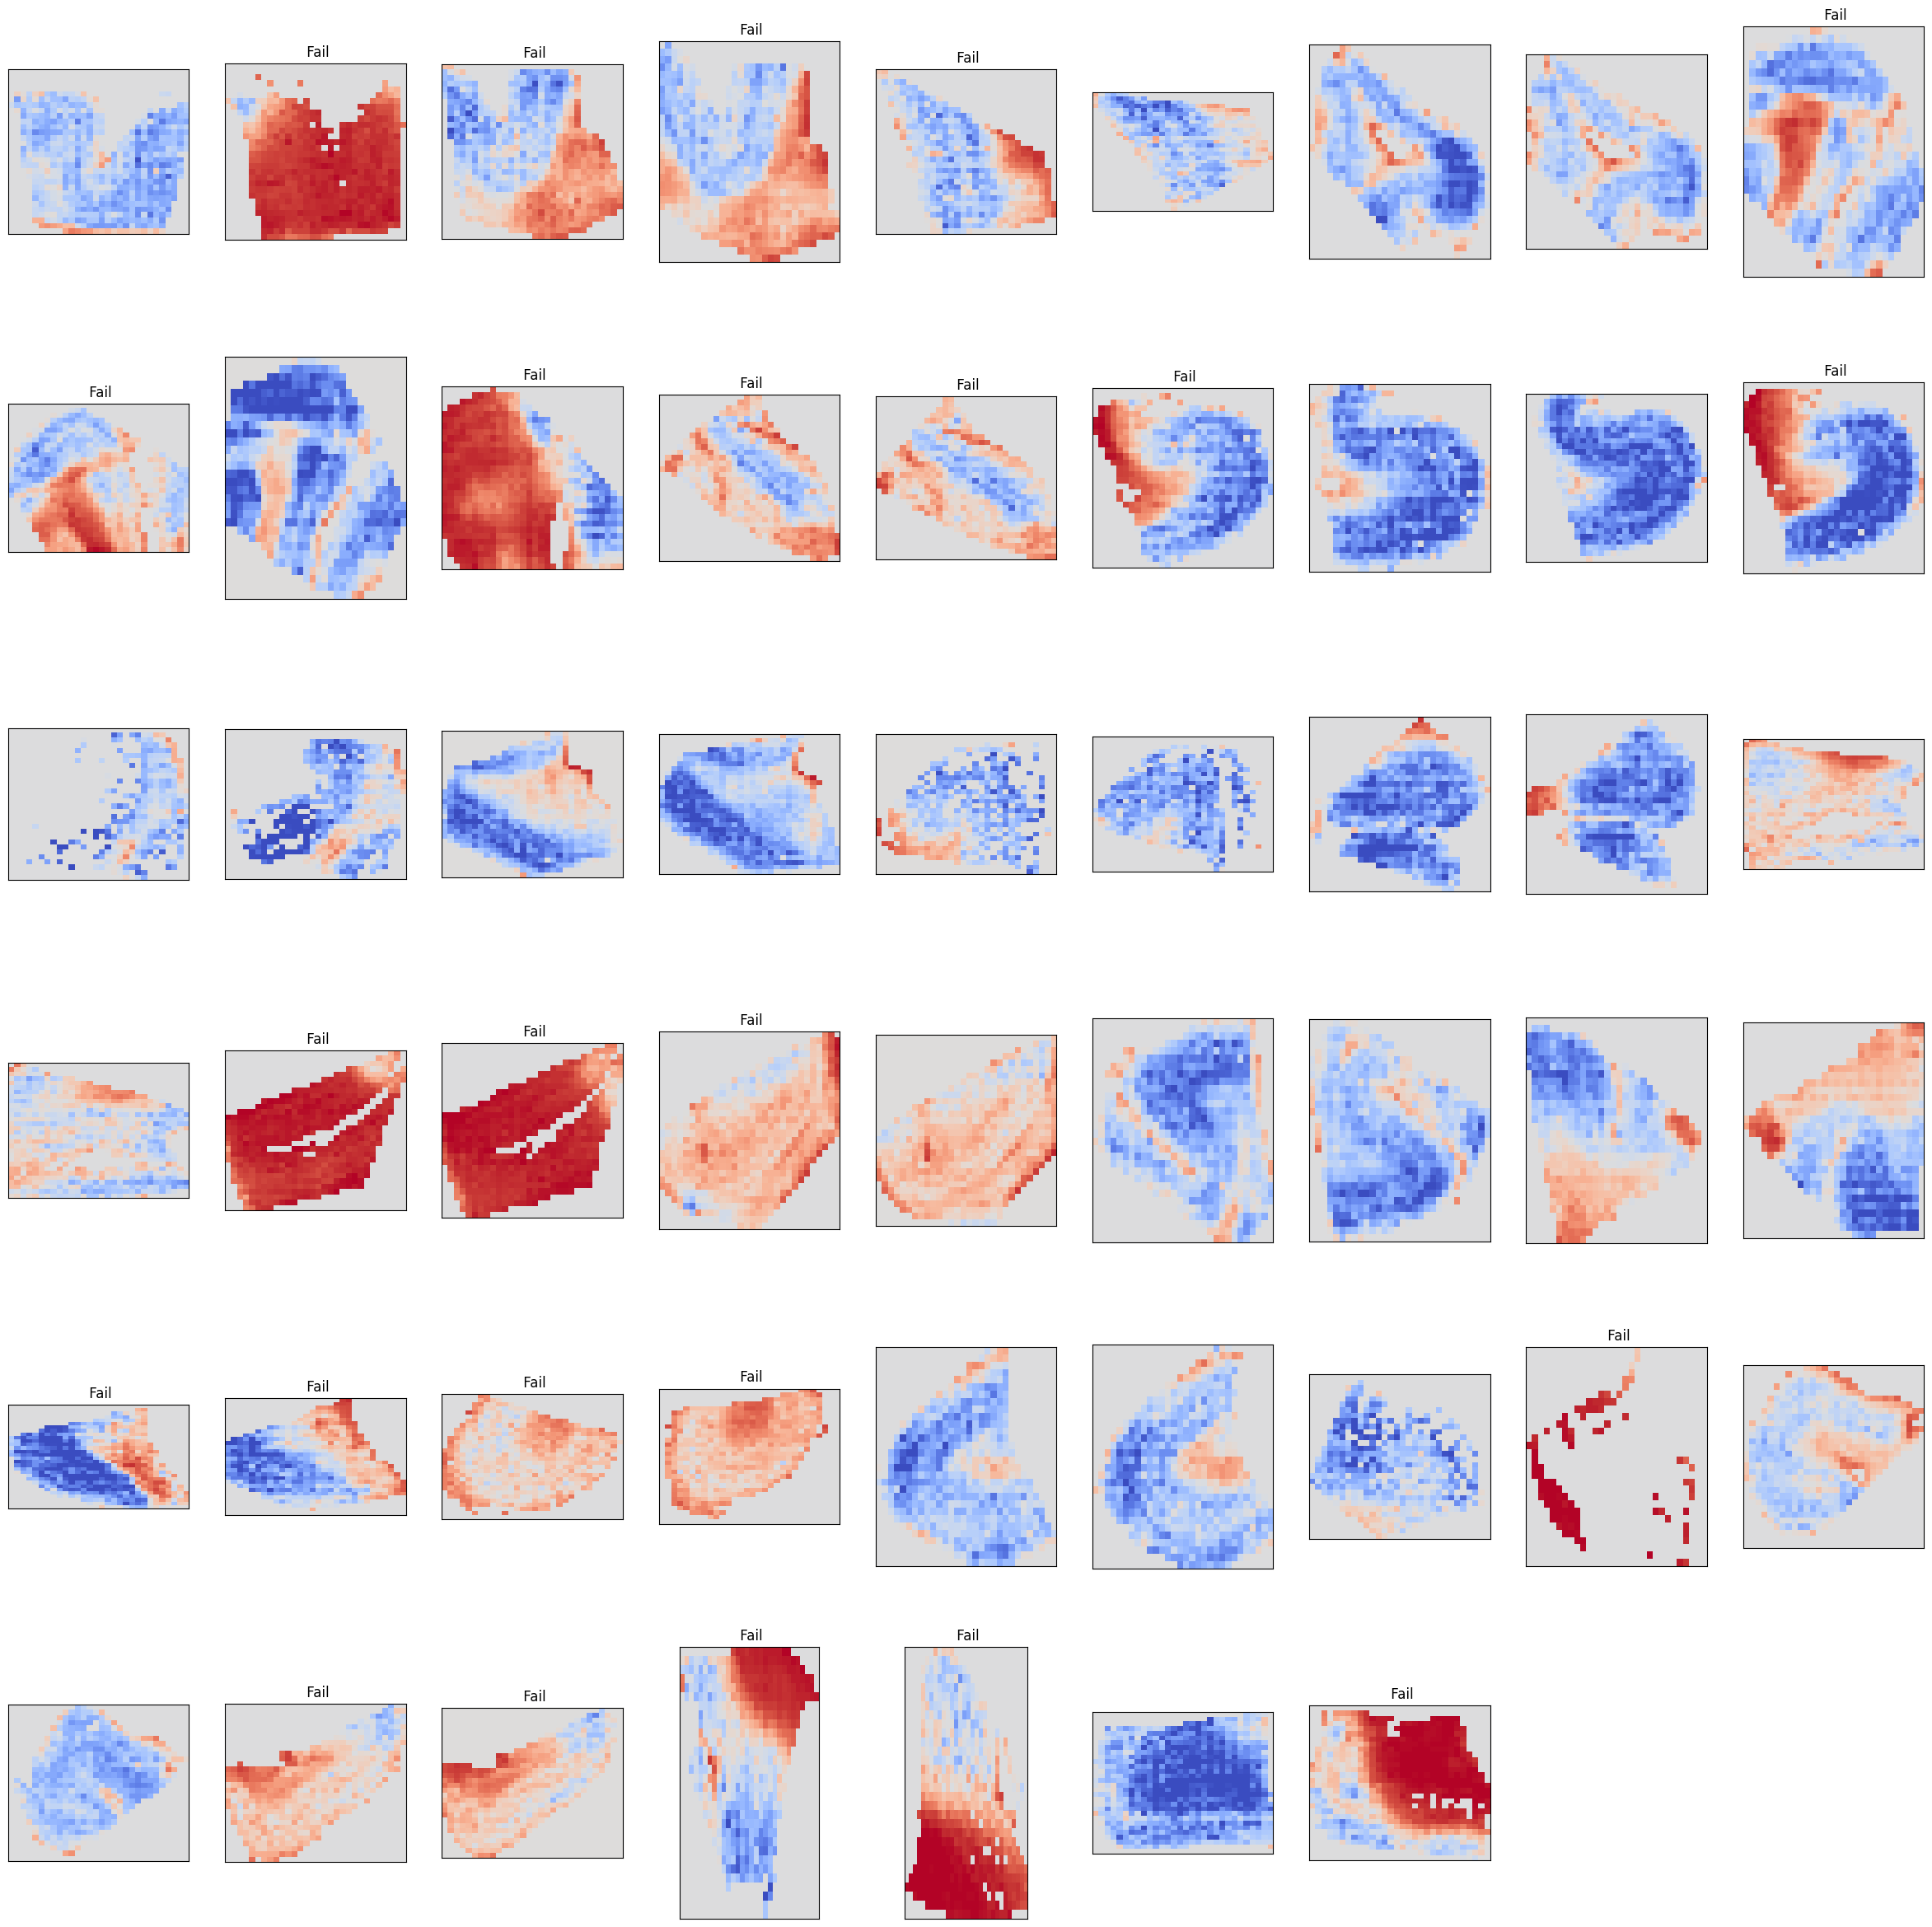

In [ ]:
a=summarize_and_plot(ad_against_spatial, figsize=[30,30])

# And the final analysis on a dataset of macaque MERSCOPE data

In [ ]:

mac_ad = ad.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/NHP_spatial/For_Cirro/macaque_HMBA_BG_QM23.50.001.h5ad")

In [ ]:
mac_ad.obs["x_centroid"]=mac_ad.obs.center_x
mac_ad.obs["y_centroid"]=mac_ad.obs.center_y

In [ ]:
# loop over individual sections, comparing each to the whole dataset as reference
# precompute reference means/stds once so they aren't recalculated for every section
mac_all_means = mac_ad.obs.groupby('Subclass_Corr', observed=True)['n_transcripts'].mean()
mac_all_stds = mac_ad.obs.groupby('Subclass_Corr', observed=True)['n_transcripts'].std()

mac_against_spatial = {}
for ii,z in enumerate(sorted(list( mac_ad.obs.barcode.unique()))):

    s = spatial_detection_scores(mac_ad[mac_ad.obs.barcode==z,:].obs, mac_all_means, mac_all_stds, query_name=str(z),
                                 category ='Subclass_Corr', n_bins=30, plot_stuff=False, comparison_column="n_transcripts")
    mac_against_spatial[z]=s


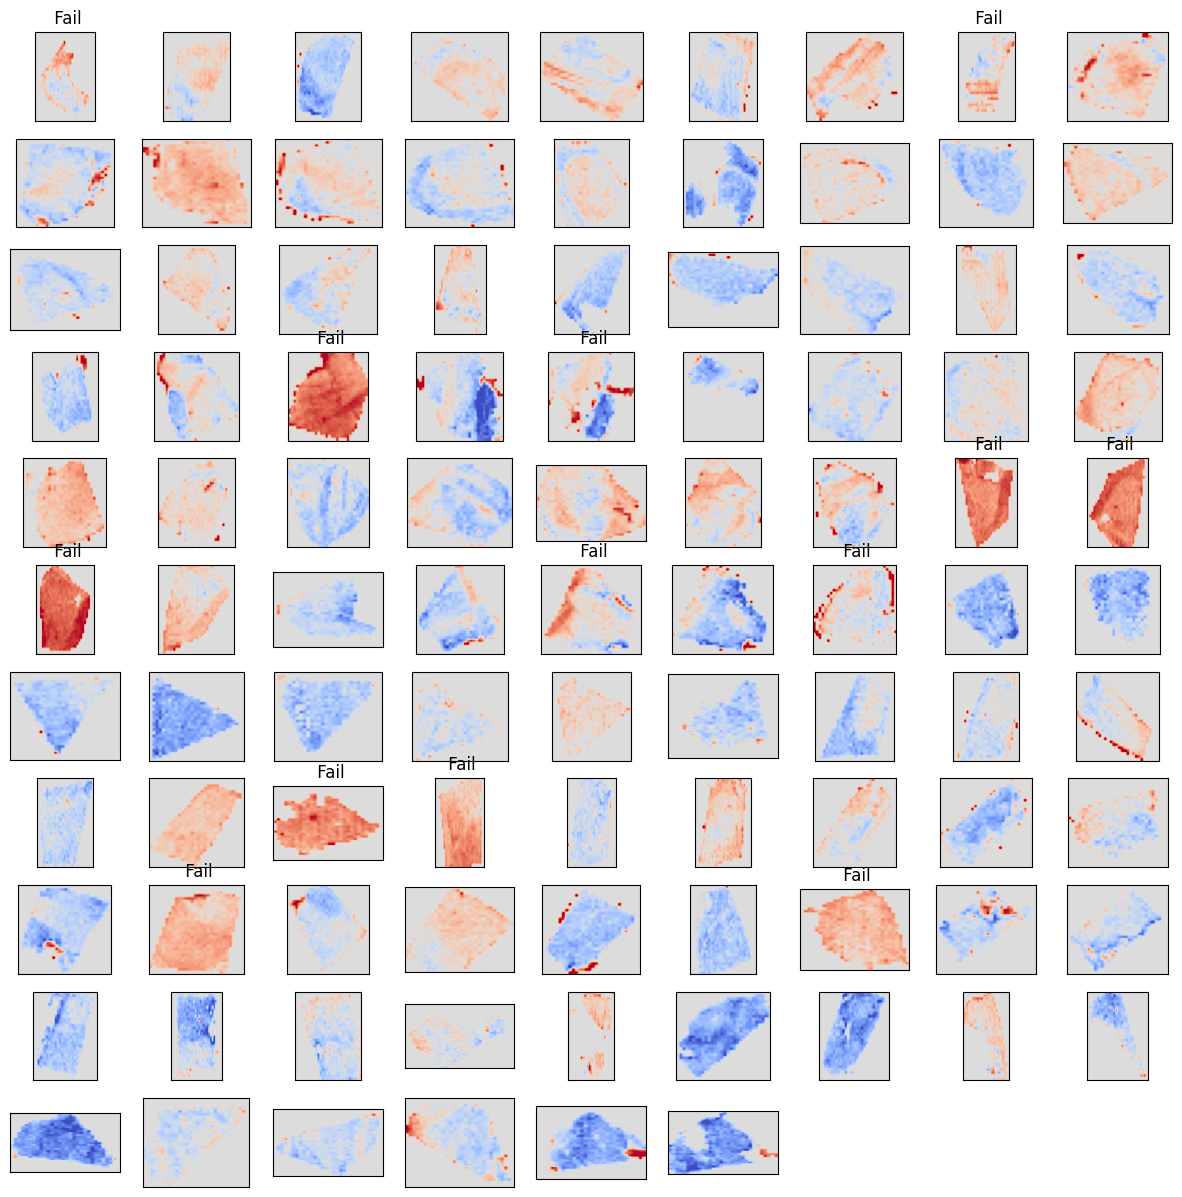

In [ ]:
a = summarize_and_plot(mac_against_spatial)

# steps below can load RNASeq taxonomy to use as reference. 
needs to be tweaked to match the `Subclass_label` column in the RNAseq to the corresponding subclass label in the spatial data

In [ ]:

mac_ref = ad.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/shiny/10x_seq/NHP_BG_AIT_116/AI_taxonomy.h5ad")

In [ ]:
mac_ref

AnnData object with n_obs × n_vars = 135219 × 35219
    obs: 'sample_name_old', 'Class_id', 'Class_label', 'Class_color', 'Neighborhood_id', 'Neighborhood_label', 'Neighborhood_color', 'Subclass_id', 'Subclass_label', 'Subclass_color', 'Cluster_id', 'Cluster_label', 'Cluster_color', 'Donor_id', 'Donor_label', 'Donor_color', 'Load_id', 'Load_label', 'Load_color', 'Sex_id', 'Sex_label', 'Sex_color', 'Age_id', 'Age_label', 'Age_color', 'Species_id', 'Species_label', 'Species_color', 'Region_id', 'Region_label', 'Region_color', 'umi.counts_id', 'umi.counts_label', 'umi.counts_color', 'gene.counts.0_id', 'gene.counts.0_label', 'gene.counts.0_color', 'cluster_id', 'cluster_label', 'cluster_color', 'cluster', 'sample_id', 'off_target'
    var: 'gene', 'highly_variable_genes'
    uns: 'QC_markers', 'cellSet', 'clusterInfo', 'clustersUse', 'dend', 'filter', 'memb', 'mode', 'stats', 'taxonomyDir', 'taxonomyName'
    obsm: 'umap'
    layers: 'counts'

In [ ]:
mac_ref.obs.columns

Index(['sample_name_old', 'Class_id', 'Class_label', 'Class_color',
       'Neighborhood_id', 'Neighborhood_label', 'Neighborhood_color',
       'Subclass_id', 'Subclass_label', 'Subclass_color', 'Cluster_id',
       'Cluster_label', 'Cluster_color', 'Donor_id', 'Donor_label',
       'Donor_color', 'Load_id', 'Load_label', 'Load_color', 'Sex_id',
       'Sex_label', 'Sex_color', 'Age_id', 'Age_label', 'Age_color',
       'Species_id', 'Species_label', 'Species_color', 'Region_id',
       'Region_label', 'Region_color', 'umi.counts_id', 'umi.counts_label',
       'umi.counts_color', 'gene.counts.0_id', 'gene.counts.0_label',
       'gene.counts.0_color', 'cluster_id', 'cluster_label', 'cluster_color',
       'cluster', 'sample_id', 'off_target'],
      dtype='object')

In [ ]:
compare_reference_and_spatial(mac_ref,mac_ad, 
                                  category="Subclass_label", layer_field = "counts", 
                                  plot_stuff=True,
                                  target_obs_key = "n_transcripts", ok_to_clobber=True)


In [ ]:
# loop over individual sections, comparing each to the whole dataset as reference
# precompute reference means/stds once so they aren't recalculated for every section
mac_all_means = mac_ad.obs.groupby('Subclass_Corr', observed=True)['n_transcripts'].mean()
mac_all_stds = mac_ad.obs.groupby('Subclass_Corr', observed=True)['n_transcripts'].std()

mac_against_spatial = {}
for ii,z in enumerate(sorted(list( mac_ad.obs.barcode.unique()))):

    s = spatial_detection_scores(mac_ad[mac_ad.obs.barcode==z,:].obs, mac_all_means, mac_all_stds, query_name=str(z),
                                 category ='Subclass_Corr', n_bins=30, plot_stuff=False, comparison_column="n_transcripts")
    mac_against_spatial[z]=s
